Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

## Visualisation

In [2]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

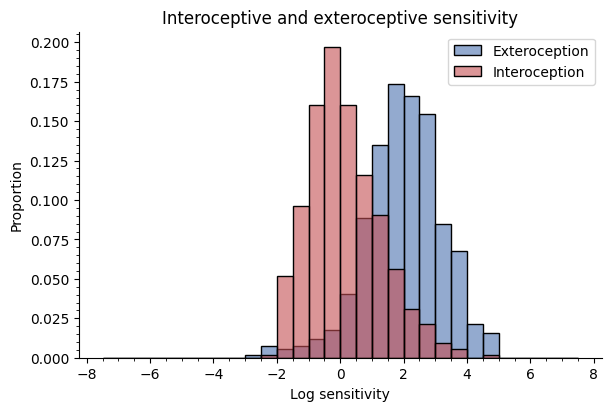

In [3]:
_, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    weighted_update_df.logit_exteroceptive_sensitivity.to_numpy(),
    color="#4c72b0",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    binrange=(-7.5, 7.5),
    label="Exteroception",
    ax=ax,
)

sns.histplot(
    weighted_update_df.logit_interoceptive_sensitivity.to_numpy(),
    color="#c44e52",
    alpha=0.6,
    stat="proportion",
    binwidth=.5,
    binrange=(-7.5, 7.5),
    label="Interoception",
    ax=ax,
)
ax.set(
    title="Interoceptive and exteroceptive sensitivity",
    xlabel="Log sensitivity",
)
ax.legend()
ax.minorticks_on()
sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_intero_extero.svg")

In [4]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

In [5]:
merged

,participant_id,session_del1,cardiac_belief_del1,intero_sensitivity_del1,extero_sensitivity_del1,pi_cardiac_belief_del1,pi_extero_belief_del1,sigma_cardiac_prior_del1,sigma_extero_prior_del1,mu_cardiac_prior_del1,...,intero_sensitivity_del2,extero_sensitivity_del2,pi_cardiac_belief_del2,pi_extero_belief_del2,sigma_cardiac_prior_del2,sigma_extero_prior_del2,mu_cardiac_prior_del2,mu_extero_prior_del2,logit_interoceptive_sensitivity_del2,logit_exteroceptive_sensitivity_del2
0,sub-0019,1,77.800193,0.601689,0.948646,0.028865,0.026840,15.104402,19.098625,102.191143,...,0.837858,0.955494,0.076979,0.036743,12.316812,18.069182,117.872884,98.064004,1.642376,3.066613
1,sub-0022,1,65.293271,0.263749,0.970500,0.084857,0.023812,5.177848,20.730446,63.580838,...,0.243138,0.981995,0.052465,0.104329,5.699873,17.373018,43.134199,56.815667,-1.135553,3.998916
2,sub-0023,1,73.018607,0.593279,0.900066,0.080232,0.011730,8.640737,19.546674,52.975321,...,0.356454,0.760280,0.053095,0.047174,6.898592,8.592742,55.464181,93.354812,-0.590788,1.154215
3,sub-0024,1,82.321040,0.729838,0.596386,0.120317,0.004465,8.186272,20.466195,116.195401,...,0.188561,0.971115,0.007197,0.032606,16.769312,20.200617,84.746798,96.497940,-1.459389,3.515123
4,sub-0025,1,54.737025,0.210903,0.676217,0.088608,0.012253,4.898454,13.218277,47.859519,...,0.245964,0.511960,0.073065,0.062358,5.174261,5.080680,44.917854,51.081108,-1.120253,0.047851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,sub-0251,1,75.783064,0.923666,0.820242,0.206745,0.007626,18.350166,17.838308,81.149252,...,0.932144,0.904541,0.219041,0.017921,16.871776,17.497302,75.812175,76.753367,2.620106,2.248725
183,sub-0252,1,88.601883,0.187876,0.922933,0.085815,0.024067,4.664355,17.370718,90.592102,...,0.798941,0.819469,0.182235,0.020615,13.651291,13.471437,98.453940,87.647413,1.379691,1.512753
184,sub-0253,1,63.375360,0.630096,0.976860,0.012803,0.079250,17.751516,18.456924,75.589731,...,0.912264,0.843468,0.132282,0.019023,14.974775,15.843931,106.718719,69.786109,2.341594,1.684261
185,sub-0254,1,61.198507,0.492949,0.669625,0.040750,0.033740,12.340843,8.270199,63.264651,...,0.880459,0.883053,0.123849,0.036858,17.002812,13.670027,73.994686,73.519556,1.996784,2.021664


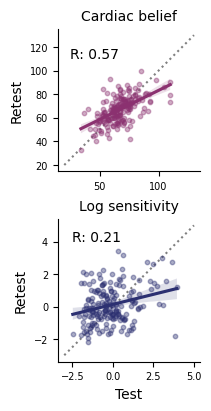

In [6]:
fig, axs = plt.subplots(figsize=(2, 4), nrows=2)

merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

sns.regplot(
    x=merged["cardiac_belief_del1"],
    y=merged["cardiac_belief_del2"],
    scatter_kws={"s": 10, "alpha": .4},
    color="#8b3170",
    ax=axs[0]
)
axs[0].annotate(
    f"R: {round(pg.corr(
    x=merged["cardiac_belief_del1"].to_numpy(),
    y=merged["cardiac_belief_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (25, 110)
)

sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"],
    y=merged["logit_interoceptive_sensitivity_del2"],
    color="#2c3071",
    scatter_kws={"s": 10, "alpha": .4},
    ax=axs[1]
)
axs[1].annotate(
    f"R: {round(pg.corr(
    x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (-2.5, 4)
)

axs[0].plot((20, 130), (20, 130), linestyle=":", color="gray", zorder=0)
axs[0].tick_params(axis='both', labelsize=7)
axs[0].set_title("Cardiac belief", fontsize=10)
axs[1].plot((-3, 5), (-3,5), linestyle=":", color="gray", zorder=0)
axs[1].tick_params(axis='both', labelsize=7)
axs[1].set_title("Log sensitivity", fontsize=10)

axs[0].set(xlabel=None, ylabel="Retest")
axs[1].set(xlabel="Test", ylabel="Retest")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_reliability.svg")